In [1]:
from __future__ import annotations

import os
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

Supplementary Figures 3 and 4 - effect of depletion conditions on mRNA and total RNA
-

TECAN poly A RNA-seq 
-
1) 2 replicates 

2) samples:
    - control
    - even pooling low concentration 
    - even pooling high concentration
    - adjusted pooling high concentration


In [29]:
# -----------------------------------------------------------------------------
# Plot style
# -----------------------------------------------------------------------------

def set_pub_style(base_fontsize: int = 11) -> None:
    """Set a clean publication-style matplotlib theme."""
    plt.rcParams.update({
        "font.size": base_fontsize,
        "axes.titlesize": base_fontsize + 1,
        "axes.labelsize": base_fontsize,
        "xtick.labelsize": base_fontsize - 1,
        "ytick.labelsize": base_fontsize - 1,
        "legend.fontsize": base_fontsize - 1,
        "figure.titlesize": base_fontsize + 2,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 1.0,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "savefig.dpi": 300,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


# -----------------------------------------------------------------------------
# File loading and validation
# -----------------------------------------------------------------------------

def read_rsem_isoform_results(path: str | Path) -> pd.DataFrame:
    """
    Read an RSEM isoform results file and return transcript_id + TPM only.

    Expected columns include:
      transcript_id, gene_id, length, effective_length, expected_count, TPM, FPKM, IsoPct
    """
    path = Path(path)
    df = pd.read_csv(path, sep="\t", usecols=["transcript_id", "TPM"])
    df["TPM"] = pd.to_numeric(df["TPM"], errors="coerce").fillna(0.0)
    df = df.drop_duplicates(subset="transcript_id").copy()
    return df


def validate_replicates(control: Dict[str, str],
                        DEL: Dict[str, str],
                        DEH: Dict[str, str],
                        DAH: Dict[str, str]) -> List[str]:
    """
    Ensure all conditions share the same replicate IDs.
    Returns sorted replicate IDs.
    """
    rep_sets = {
        "control": set(control.keys()),
        "DEL": set(DEL.keys()),
        "DEH": set(DEH.keys()),
        "DAH": set(DAH.keys()),
    }

    first_name, first_set = next(iter(rep_sets.items()))
    for name, rep_set in rep_sets.items():
        if rep_set != first_set:
            raise ValueError(
                f"Replicate IDs do not match across conditions.\n"
                f"{first_name}: {sorted(first_set)}\n"
                f"{name}: {sorted(rep_set)}"
            )

    return sorted(first_set)


def load_all_conditions(control: Dict[str, str],
                        DEL: Dict[str, str],
                        DEH: Dict[str, str],
                        DAH: Dict[str, str]) -> Dict[str, Dict[str, pd.DataFrame]]:
    """
    Load all files into nested dict:
      data[condition][rep] = dataframe(transcript_id, TPM)
    """
    condition_dicts = {
        "control": control,
        "DEL": DEL,
        "DEH": DEH,
        "DAH": DAH,
    }

    reps = validate_replicates(control, DEL, DEH, DAH)

    data: Dict[str, Dict[str, pd.DataFrame]] = {}
    for condition, rep_map in condition_dicts.items():
        data[condition] = {}
        for rep in reps:
            data[condition][rep] = read_rsem_isoform_results(rep_map[rep])

    return data


# -----------------------------------------------------------------------------
# Summary helpers
# -----------------------------------------------------------------------------

def count_isoforms_above_threshold(df: pd.DataFrame, threshold: float) -> int:
    """Count isoforms with TPM >= threshold."""
    return int((df["TPM"] >= threshold).sum())


def get_union_detected_isoforms(condition_rep_dfs: Dict[str, pd.DataFrame],
                                threshold: float = 1.0) -> set:
    """
    For a condition, take all replicates, find isoforms with TPM >= threshold in each,
    and return the union across replicates.
    """
    union_set = set()
    for rep, df in condition_rep_dfs.items():
        detected = set(df.loc[df["TPM"] >= threshold, "transcript_id"])
        union_set |= detected
    return union_set


def merge_control_vs_condition(control_df: pd.DataFrame,
                               cond_df: pd.DataFrame) -> pd.DataFrame:
    """
    Outer-join control and condition on transcript_id.
    Missing TPM values become 0.
    """
    merged = control_df.merge(
        cond_df,
        on="transcript_id",
        how="outer",
        suffixes=("_control", "_cond")
    )
    merged["TPM_control"] = merged["TPM_control"].fillna(0.0)
    merged["TPM_cond"] = merged["TPM_cond"].fillna(0.0)
    return merged


def summarize_detection_counts(data: Dict[str, Dict[str, pd.DataFrame]],
                               thresholds: List[float] = [0.1, 1.0, 10.0]) -> pd.DataFrame:
    """
    For each condition, replicate, and threshold, count isoforms above threshold.
    """
    records = []
    for condition, rep_map in data.items():
        for rep, df in rep_map.items():
            for thr in thresholds:
                records.append({
                    "condition": condition,
                    "replicate": rep,
                    "threshold": thr,
                    "n_isoforms": count_isoforms_above_threshold(df, thr),
                })
    return pd.DataFrame(records)


def summarize_pairwise_changes(data: Dict[str, Dict[str, pd.DataFrame]],
                               pseudocount: float = 0.01,
                               detection_threshold: float = 1.0) -> pd.DataFrame:
    """
    For each matched replicate, compare DEL/DEH/DAH vs control.

    Metrics:
      1. median fold change in TPM over isoforms that increased in TPM
         = median((TPM_cond + pc) / (TPM_control + pc)) for TPM_cond > TPM_control
      2. number of isoforms increased in TPM = count(TPM_cond > TPM_control)
      3. additional isoforms above threshold = count_cond_detected - count_control_detected

    Uses outer join on transcript_id so transcripts absent in one sample are treated as TPM=0.
    """
    comparison_conditions = ["DEL", "DEH", "DAH"]
    reps = sorted(data["control"].keys())

    records = []
    for rep in reps:
        control_df = data["control"][rep]
        n_control_detected = count_isoforms_above_threshold(control_df, detection_threshold)

        for condition in comparison_conditions:
            cond_df = data[condition][rep]
            merged = merge_control_vs_condition(control_df, cond_df)

            # only keep isoforms that increased in the condition
            increased_mask = merged["TPM_cond"] > merged["TPM_control"]
            increased_df = merged.loc[increased_mask].copy()

            n_increased = int(increased_mask.sum())

            if n_increased > 0:
                fold_change = (
                    (increased_df["TPM_cond"] + pseudocount) /
                    (increased_df["TPM_control"] + pseudocount)
                )
                median_fc = float(np.median(fold_change))
            else:
                median_fc = np.nan

            n_cond_detected = count_isoforms_above_threshold(cond_df, detection_threshold)
            n_more_detected = int(n_cond_detected - n_control_detected)

            records.append({
                "replicate": rep,
                "condition": condition,
                "median_fold_change": median_fc,
                "n_isoforms_increased_tpm": n_increased,
                "n_more_isoforms_detected_tpm1": n_more_detected,
            })

    return pd.DataFrame(records)


# -----------------------------------------------------------------------------
# Plotting functions
# -----------------------------------------------------------------------------

def plot_detection_barplot(summary_df: pd.DataFrame,
                           save_path: str | Path,
                           condition_display_names: Dict[str, str] | None = None,
                           condition_colors: Dict[str, str] | None = None,
                           figsize: Tuple[float, float] = (7, 5.5)) -> None:
    """
    Plot 1:
      Bar plot of total isoforms detected above TPM thresholds with error bars across replicates.
    """
    if condition_display_names is None:
        condition_display_names = {
            "control": "Control",
            "DEL": "Even pooling low conc",
            "DEH": "Even pooling high conc",
            "DAH": "Adjusted pooling high conc",
        }

    if condition_colors is None:
        condition_colors = {
            "control": "#4C72B0",
            "DEL": "#55A868",
            "DEH": "#C44E52",
            "DAH": "#8172B3",
        }

    thresholds = sorted(summary_df["threshold"].unique())
    conditions = ["control", "DEL", "DEH", "DAH"]

    grouped = (
        summary_df
        .groupby(["condition", "threshold"])["n_isoforms"]
        .agg(["mean", "std"])
        .reset_index()
    )

    set_pub_style()
    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(thresholds))
    width = 0.18
    offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * width

    for i, condition in enumerate(conditions):
        sub = grouped[grouped["condition"] == condition].sort_values("threshold")
        ax.bar(
            x + offsets[i],
            sub["mean"].values,
            width=width,
            yerr=sub["std"].fillna(0).values,
            capsize=4,
            color=condition_colors[condition],
            edgecolor="black",
            linewidth=0.8,
            label=condition_display_names[condition],
        )

    ax.set_xticks(x)
    ax.set_xticklabels([str(t) for t in thresholds])
    ax.set_xlabel("TPM threshold", fontsize=12)
    ax.set_ylabel("Number of isoforms detected", fontsize=12)
    ax.set_title("Isoform detection across TPM thresholds", fontsize=14)
    ax.legend(frameon=False)
    plt.tight_layout()

    save_path = Path(save_path)
    fig.savefig(save_path, dpi=300)
    plt.show()
    plt.close(fig)


def plot_venn_comparisons(data: Dict[str, Dict[str, pd.DataFrame]],
                          save_path: str | Path,
                          detection_threshold: float = 1.0,
                          figsize: Tuple[float, float] = (12, 4.5)) -> None:
    """
    Plot 2:
      1 row with 3 venn diagrams:
        control vs DEL
        control vs DEH
        control vs DAH
    Union across replicates within each condition.
    """
    set_pub_style()
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    comparisons = [
        ("DEL", "Control vs even pooling low conc"),
        ("DEH", "Control vs even pooling high conc"),
        ("DAH", "Control vs adjusted pooling high conc"),
    ]

    control_set = get_union_detected_isoforms(data["control"], threshold=detection_threshold)

    for ax, (condition, title) in zip(axes, comparisons):
        cond_set = get_union_detected_isoforms(data[condition], threshold=detection_threshold)

        venn2(
            subsets=(control_set, cond_set),
            set_labels=("Control", title.replace("Control vs ", "")),
            ax=ax
        )
        ax.set_title(title)

    fig.suptitle(f"Union of detected isoforms across replicates (TPM ≥ {detection_threshold})", y=0.92)
    plt.tight_layout()

    save_path = Path(save_path)
    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)


def plot_pairwise_summary_bars(summary_df: pd.DataFrame,
                               save_path: str | Path,
                               condition_display_names: Dict[str, str] | None = None,
                               condition_colors: Dict[str, str] | None = None,
                               figsize: Tuple[float, float] = (10, 4.5)) -> None:
    """
    Plot 3:
      1 row with 3 subplots
        1. median fold change in TPM
        2. total number of isoforms increased in TPM
        3. number of more isoforms identified above TPM 1
    Error bars are std across matched replicates.
    """
    if condition_display_names is None:
        condition_display_names = {
            "DEL": "Even pooling low",
            "DEH": "Even pooling high",
            "DAH": "Adjusted high",
        }

    if condition_colors is None:
        condition_colors = {
            "DEL": "#55A868",
            "DEH": "#C44E52",
            "DAH": "#8172B3",
        }

    metrics = [
        ("median_fold_change", "Median fold change in TPM"),
        ("n_isoforms_increased_tpm", "Isoforms increased in TPM"),
        ("n_more_isoforms_detected_tpm1", "Additional isoforms detected\n(TPM ≥ 1)"),
    ]

    order = ["DEL", "DEH", "DAH"]

    grouped = (
        summary_df
        .groupby("condition")[[
            "median_fold_change",
            "n_isoforms_increased_tpm",
            "n_more_isoforms_detected_tpm1"
        ]]
        .agg(["mean", "std"])
    )

    set_pub_style()
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    for ax, (metric, ylabel) in zip(axes, metrics):
        means = [grouped.loc[c, (metric, "mean")] for c in order]
        stds = [grouped.loc[c, (metric, "std")] if pd.notnull(grouped.loc[c, (metric, "std")]) else 0 for c in order]
        labels = [condition_display_names[c] for c in order]
        colors = [condition_colors[c] for c in order]

        ax.bar(
            np.arange(len(order)),
            means,
            yerr=stds,
            capsize=4,
            color=colors,
            edgecolor="black",
            linewidth=0.8
        )

        ax.set_xticks(np.arange(len(order)))
        ax.set_xticklabels(labels, rotation=20, ha="right")
        ax.set_ylabel(ylabel)

        if metric == "median_fold_change":
            ax.axhline(1.0, color="black", linestyle="--", linewidth=1)

    fig.suptitle("Matched replicate changes relative to control", y=1.03)
    plt.tight_layout()

    save_path = Path(save_path)
    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)


# -----------------------------------------------------------------------------
# Master function
# -----------------------------------------------------------------------------

def make_isoform_tpm_supplementary_plots(control: Dict[str, str],
                                         DEL: Dict[str, str],
                                         DEH: Dict[str, str],
                                         DAH: Dict[str, str],
                                         save_dir: str | Path,
                                         file_prefix: str = "isoform_tpm_summary",
                                         pseudocount: float = 0.01,
                                         detection_thresholds: List[float] = [0.1, 1.0, 10.0],
                                         venn_threshold: float = 1.0) -> Dict[str, str]:
    """
    Generate and save all 3 supplementary figures.

    Parameters
    ----------
    control, DEL, DEH, DAH : dict
        Keys are replicate IDs, values are paths to RSEM isoform result files.

    save_dir : str or Path
        Directory where the three plots will be saved.

    file_prefix : str
        Prefix for output file names.

    pseudocount : float
        Pseudocount for fold-change calculation.

    detection_thresholds : list of float
        TPM thresholds for the first bar plot.

    venn_threshold : float
        TPM threshold used for venn diagram union sets and "additional isoforms detected".

    Returns
    -------
    dict
        Paths to saved figures.
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    data = load_all_conditions(control, DEL, DEH, DAH)

    detection_summary = summarize_detection_counts(
        data,
        thresholds=detection_thresholds
    )

    pairwise_summary = summarize_pairwise_changes(
        data,
        pseudocount=pseudocount,
        detection_threshold=venn_threshold
    )

    plot1_path = save_dir / f"{file_prefix}_barplot_detection_thresholds.png"
    plot2_path = save_dir / f"{file_prefix}_venn_detected_isoforms.png"
    plot3_path = save_dir / f"{file_prefix}_pairwise_summary_bars.png"

    plot_detection_barplot(detection_summary, plot1_path)
    plot_venn_comparisons(data, plot2_path, detection_threshold=venn_threshold)
    plot_pairwise_summary_bars(pairwise_summary, plot3_path)

    return {
        "plot_1_detection_barplot": str(plot1_path),
        "plot_2_venn_diagrams": str(plot2_path),
        "plot_3_pairwise_summary": str(plot3_path),
    }

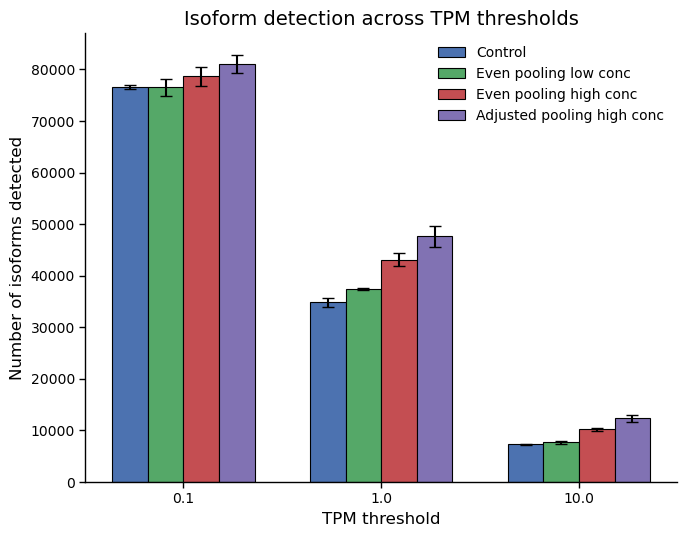

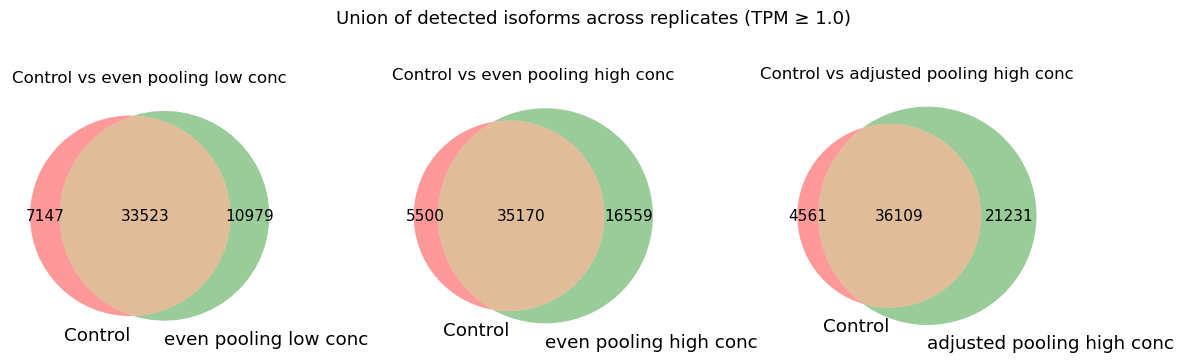

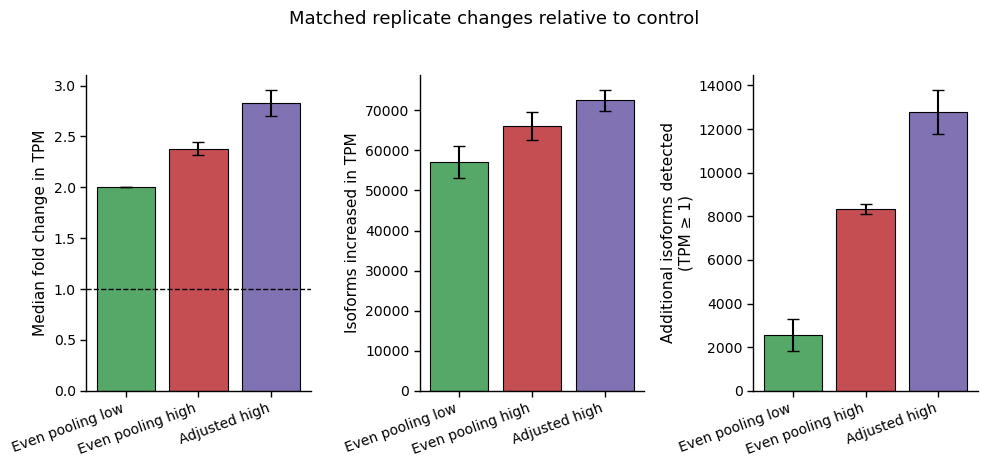

{'plot_1_detection_barplot': 'NEW_guide_analysis_GREGOR/isoforms_TECAN_supplementary/TECAN_barplot_detection_thresholds.png', 'plot_2_venn_diagrams': 'NEW_guide_analysis_GREGOR/isoforms_TECAN_supplementary/TECAN_venn_detected_isoforms.png', 'plot_3_pairwise_summary': 'NEW_guide_analysis_GREGOR/isoforms_TECAN_supplementary/TECAN_pairwise_summary_bars.png'}


In [30]:
control = {
    "rep1": "NEW_guide_analysis_GREGOR/f11_H4_TECAN_control_S1.isoforms.results",
    "rep2": "NEW_guide_analysis_GREGOR/g11_G2_TECAN_control_S2.isoforms.results",
}

DEL = {
    "rep1": "NEW_guide_analysis_GREGOR/f11_H4_TECAN_DEL_S1.isoforms.results",
    "rep2": "NEW_guide_analysis_GREGOR/g11_G2_TECAN_DEL_S2.isoforms.results",
}

DEH = {
    "rep1": "NEW_guide_analysis_GREGOR/f11_H4_TECAN_DEH_S1.isoforms.results",
    "rep2": "NEW_guide_analysis_GREGOR/g11_G2_TECAN_DEH_S2.isoforms.results",
}

DAH = {
    "rep1": "NEW_guide_analysis_GREGOR/f11_H4_TECAN_DAH_S1.isoforms.results",
    "rep2": "NEW_guide_analysis_GREGOR/g11_G2_TECAN_DAH_S2.isoforms.results",
}

out = make_isoform_tpm_supplementary_plots(
    control=control,
    DEL=DEL,
    DEH=DEH,
    DAH=DAH,
    save_dir="NEW_guide_analysis_GREGOR/isoforms_TECAN_supplementary",
    file_prefix="TECAN"
)

print(out)

WATCHMAKER total RNA-seq 
-
1) 2 replicates 

2) samples:
    - control
    - even pooling low concentration 
    - even pooling high concentration
    - adjusted pooling high concentration


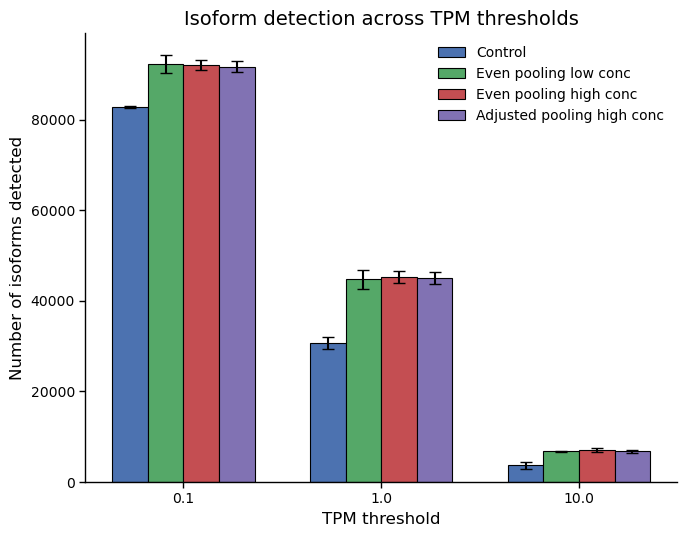

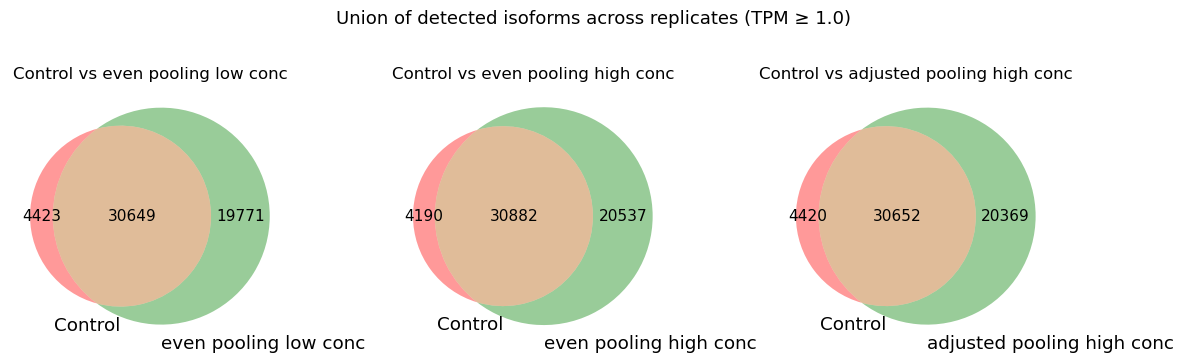

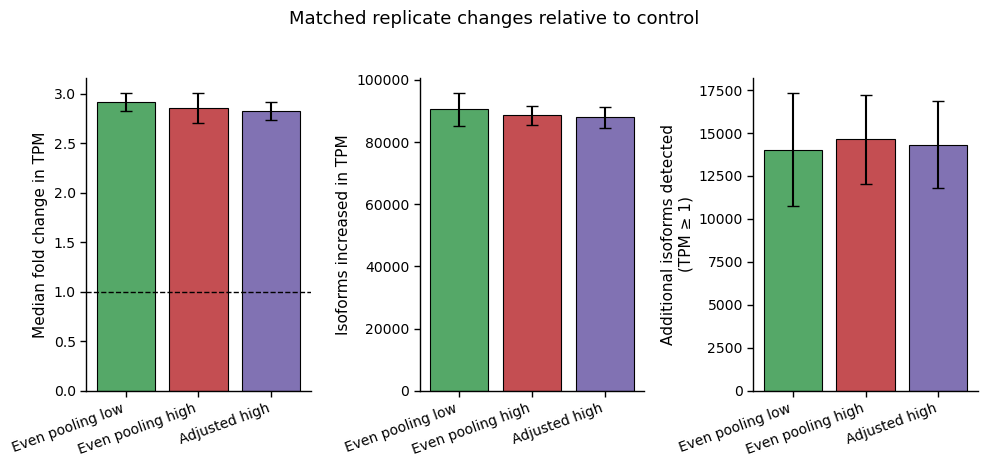

{'plot_1_detection_barplot': 'NEW_guide_analysis_GREGOR/isoforms_WATCHMAKER_supplementary/WATCHMAKER_barplot_detection_thresholds.png', 'plot_2_venn_diagrams': 'NEW_guide_analysis_GREGOR/isoforms_WATCHMAKER_supplementary/WATCHMAKER_venn_detected_isoforms.png', 'plot_3_pairwise_summary': 'NEW_guide_analysis_GREGOR/isoforms_WATCHMAKER_supplementary/WATCHMAKER_pairwise_summary_bars.png'}


In [31]:
control = {
    "rep1": "NEW_guide_analysis_GREGOR/c1_G2_WM_control_S4.isoforms.results",
    "rep2": "NEW_guide_analysis_GREGOR/e1_H4_WM_control_S6.isoforms.results",
}

DEL = {
    "rep1": "NEW_guide_analysis_GREGOR/c1_G2_WM_DEL_S3.isoforms.results",
    "rep2": "NEW_guide_analysis_GREGOR/e1_H4_WM_DEL_S4.isoforms.results",
}

DEH = {
    "rep1": "NEW_guide_analysis_GREGOR/c1_G2_WM_DEH_S3.isoforms.results",
    "rep2": "NEW_guide_analysis_GREGOR/e1_H4_WM_DEH_S4.isoforms.results",
}

DAH = {
    "rep1": "NEW_guide_analysis_GREGOR/c1_G2_WM_DAH_S4.isoforms.results",
    "rep2": "NEW_guide_analysis_GREGOR/e1_H4_WM_DAH_S6.isoforms.results",
}

out = make_isoform_tpm_supplementary_plots(
    control=control,
    DEL=DEL,
    DEH=DEH,
    DAH=DAH,
    save_dir="NEW_guide_analysis_GREGOR/isoforms_WATCHMAKER_supplementary",
    file_prefix="WATCHMAKER"
)

print(out)